1. Checking for missing values using isnull()
2. Checking for missing values using notnull()
3. Filling missing values using fillna(), replace() and interpolate()
4. Dropping missing values using dropna()
5. Detect and Remove the Outliers
6. Data transformation 

In [109]:
import pandas as pd
import numpy as np
import seaborn as sb
import scipy as stats
import matplotlib.pyplot as plt

In [110]:
dataset = pd.read_csv("StudentsPerformance.csv")

In [111]:
dataset.head()

,Math_score,Reading_score,Writing_score,Placement_score,Club_Join_Date,Placement_Offer_Count
0,80.0,90.0,70.0,77,2018,2
1,70.0,77.0,76.0,85,2018,3
2,62.0,88.0,68.0,92,2019,3
3,94.0,84.0,71.0,78,2019,2
4,78.0,81.0,62.0,100,2020,3


In [112]:
dataset.tail()

,Math_score,Reading_score,Writing_score,Placement_score,Club_Join_Date,Placement_Offer_Count
25,76.0,83.0,79.0,77,2019,2
26,68.0,87.0,76.0,95,2020,3
27,61.0,75.0,63.0,93,2020,3
28,80.0,NaN,61.0,100,2020,3
29,65.0,78.0,73.0,98,2018,3


In [113]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Math_score             29 non-null     float64
 1   Reading_score          29 non-null     float64
 2   Writing_score          29 non-null     float64
 3   Placement_score        30 non-null     int64  
 4   Club_Join_Date         30 non-null     int64  
 5   Placement_Offer_Count  30 non-null     int64  
dtypes: float64(3), int64(3)
memory usage: 1.5 KB


In [114]:
dataset.describe()

,Math_score,Reading_score,Writing_score,Placement_score,Club_Join_Date,Placement_Offer_Count
count,29.000000,29.000000,29.000000,30.000000,30.000000,30.000000
mean,75.103448,88.068966,69.620690,85.633333,2019.466667,2.433333
std,21.699810,22.238851,5.734693,8.833648,0.899553,0.568321
min,61.000000,75.000000,61.000000,75.000000,2018.000000,1.000000
25%,65.000000,80.000000,64.000000,77.250000,2019.000000,2.000000
50%,70.000000,83.000000,70.000000,82.000000,2020.000000,2.000000
75%,78.000000,90.000000,74.000000,93.000000,2020.000000,3.000000
max,180.000000,200.000000,79.000000,100.000000,2021.000000,3.000000


In [115]:
dataset.shape

(30, 6)

In [116]:
# 1. Checking for missing values using isnull()......................................................

dataset.isnull().sum()

Math_score               1
Reading_score            1
Writing_score            1
Placement_score          0
Club_Join_Date           0
Placement_Offer_Count    0
dtype: int64

In [117]:
# 2. Checking for missing values using notnull()

dataset.notnull().sum()

Math_score               29
Reading_score            29
Writing_score            29
Placement_score          30
Club_Join_Date           30
Placement_Offer_Count    30
dtype: int64

In [118]:
#3. Filling missing values using fillna(), replace() and interpolate().............................

dataset['Math_score'] = dataset['Math_score'].fillna(dataset['Math_score'].mean()) 
dataset['Writing_score'] = dataset['Writing_score'].fillna(dataset['Writing_score'].mean()) 
dataset['Reading_score'] = dataset['Reading_score'].fillna(dataset['Reading_score'].mean()) 
dataset.isnull().sum()

Math_score               0
Reading_score            0
Writing_score            0
Placement_score          0
Club_Join_Date           0
Placement_Offer_Count    0
dtype: int64

<AxesSubplot:>

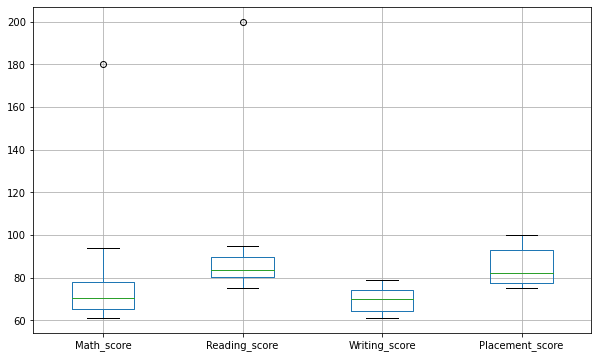

In [119]:
# 5. Detect and Remove the Outliers......................

plt.figure(figsize=(10,6))
columns = ['Math_score', 'Reading_score', 'Writing_score', 'Placement_score']
dataset.boxplot(columns)

In [120]:
# REMOVING OUTLIERS USING Z-SCORE METHOD......................
import scipy.stats as stats

#  1) Math_score
z_score=stats.zscore(dataset['Math_score'])
dataset = dataset[z_score < 3]

#  2) Reading_score
z_score = stats.zscore(dataset['Reading_score'])
dataset = dataset[z_score < 3]

<AxesSubplot:>

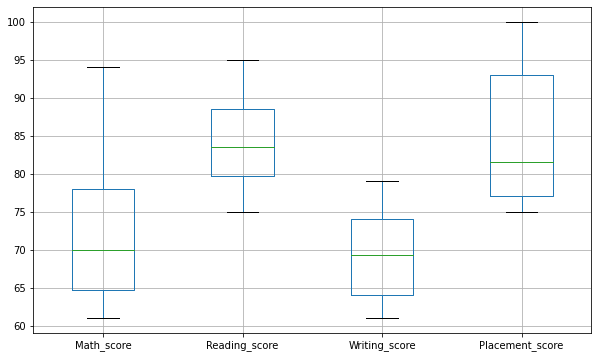

In [121]:
plt.figure(figsize=(10,6))
columns = ['Math_score', 'Reading_score', 'Writing_score', 'Placement_score']
dataset.boxplot(columns)

In [122]:
dataset

,Math_score,Reading_score,Writing_score,Placement_score,Club_Join_Date,Placement_Offer_Count
0,80.000000,90.000000,70.00000,77,2018,2
1,70.000000,77.000000,76.00000,85,2018,3
2,62.000000,88.000000,68.00000,92,2019,3
3,94.000000,84.000000,71.00000,78,2019,2
4,78.000000,81.000000,62.00000,100,2020,3
6,77.000000,75.000000,65.00000,100,2020,3
7,62.000000,80.000000,63.00000,97,2019,3
8,79.000000,88.000000,65.00000,82,2018,2
9,63.000000,94.000000,73.00000,79,2021,1
10,66.000000,79.000000,77.00000,80,2019,2


In [123]:
# 6. Data transformation
from sklearn.preprocessing import StandardScaler
df_min_max_scaled=dataset.copy()
for column in df_min_max_scaled.columns:
    df_min_max_scaled[column]= (df_min_max_scaled[column]-df_min_max_scaled[column].min()) / (df_min_max_scaled[column].max()-df_min_max_scaled[column].min())
df_min_max_scaled

,Math_score,Reading_score,Writing_score,Placement_score,Club_Join_Date,Placement_Offer_Count
0,0.575758,0.750000,0.500000,0.08,0.000000,0.5
1,0.272727,0.100000,0.833333,0.40,0.000000,1.0
2,0.030303,0.650000,0.388889,0.68,0.333333,1.0
3,1.000000,0.450000,0.555556,0.12,0.333333,0.5
4,0.515152,0.300000,0.055556,1.00,0.666667,1.0
6,0.484848,0.000000,0.222222,1.00,0.666667,1.0
7,0.030303,0.250000,0.111111,0.88,0.333333,1.0
8,0.545455,0.650000,0.222222,0.28,0.000000,0.5
9,0.060606,0.950000,0.666667,0.16,1.000000,0.0
10,0.151515,0.200000,0.888889,0.20,0.333333,0.5
